# Cubo Gelatinoso

Aluno: Ricardo Pereira Lourenço de Carvalho

Docente: Daniel R. Cassar

Instituiçao: Ilum Escola de Ciência

## Introdução

Neste notebook é estudado o desempenho de modelos de classificação baseados em **K vizinhos mais próximos (K-NN)** para prever a vitória do time azul em partidas de *League of Legends*.

Para isto, um conjunto de dados com pelo menos um atributo categórico foi escolhido, sendo assim o conjunto de dados contém informações observadas aos 10 minutos de partida. 

Para induzir os modelos baseline e K-NN deste documento foi utilizado a biblioteca do Scikit-learn.
Nesta tarefa um problema de classificação será o foco, ou seja, o **target** dos modelos será categórico. 

E a métrica de desempenho utilizada nos modelos será por sua vez a acurácia.

## Bibliotecas Utilizadas

In [1]:
# Bibliotecas para DataSet
import pandas as pd
import numpy as np

# Bibliotecas para Gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# Biblioteca Scikit para os modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Produto Cartesiano para combinações de hiperparâmetros
from itertools import product

## Conjunto de Dados

O conjunto de dados escolhido foi retirado do Kaggle e apresentam atributos relacionados os dados coletados aos 10 minutos de uma partida de League of Legends, com "high diamond" sendo o elo dos jogadores. O conjunto apresenta 40 atributos diferentes de diversas estatísticas, contudo apenas 11 serão utilizados no modelos.

O **target** do modelo K-NN será a vitoria do time azul, e os atributos que serão utilizados no modelo serão aqueles que mais influenciam neste resultado. Esta escolha arbitraria dos atributos corresponde a certas ações que afetam o resultado da partida, tendo em vista que estes dados se restringem em média a $1/3$ do tempo da partida.

In [2]:
df_dados = pd.read_csv("high_diamond_ranked_10min.csv")
df_dados = df_dados.dropna()
df_dados

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,4527873286,1,17,2,1,7,4,5,1,1,...,0,15246,6.8,16498,229,34,-2519,-2469,22.9,1524.6
9875,4527797466,1,54,0,0,6,4,8,1,1,...,0,15456,7.0,18367,206,56,-782,-888,20.6,1545.6
9876,4527713716,0,23,1,0,6,7,5,0,0,...,0,18319,7.4,19909,261,60,2416,1877,26.1,1831.9
9877,4527628313,0,14,4,1,2,3,3,1,1,...,0,15298,7.2,18314,247,40,839,1085,24.7,1529.8


### Escolha dos atributos

A escolha de atributos como número de campeões abatidos, dragões mortos, sentinelas colocadas e minions mortos representam dados que em média direcionam o resultado da partida, pois representam a diferença de ouro entre os times e o quanto de informação do mapa os times obtiveram. A distribuição de cada um destes atributos com base na vitória será discutido na apresentação de seus respectivos gráficos.

Os atributos categóricos escolhidos serão o "blueFirstBlood" e "blueDragons", que apesar de estarem em valores númericos, representam respectivamente um valor binário de se o time azul realizou o primeiro abate ou se o time azul derrotou o dragão dentro dos 10 minutos.

In [3]:
colunas = ["blueWins", "blueKills", 
           "blueWardsPlaced","blueFirstBlood",
           "blueTotalMinionsKilled","blueTotalJungleMinionsKilled",
           "blueDragons",
           "redKills", "redWardsPlaced", 
           "redTotalMinionsKilled", "redTotalJungleMinionsKilled"]

df_dados = df_dados.reindex(colunas, axis = 1)
df_dados = df_dados.copy()

### Visão superficial dos atributos e Filtragem

Abaixo podemos observar certas estatísticas descritivas dos atributos escolhidos

In [4]:
df_dados.describe()

,blueWins,blueKills,blueWardsPlaced,blueFirstBlood,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueDragons,redKills,redWardsPlaced,redTotalMinionsKilled,redTotalJungleMinionsKilled
count,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,0.499038,6.183925,22.288288,0.504808,216.699565,50.509667,0.361980,6.137666,22.367952,217.349226,51.313088
std,0.500024,3.011028,18.019177,0.500002,21.858437,9.898282,0.480597,2.933818,18.457427,21.911668,10.027885
min,0.000000,0.000000,5.000000,0.000000,90.000000,0.000000,0.000000,0.000000,6.000000,107.000000,4.000000
25%,0.000000,4.000000,14.000000,0.000000,202.000000,44.000000,0.000000,4.000000,14.000000,203.000000,44.000000
50%,0.000000,6.000000,16.000000,1.000000,218.000000,50.000000,0.000000,6.000000,16.000000,218.000000,51.000000
75%,1.000000,8.000000,20.000000,1.000000,232.000000,56.000000,1.000000,8.000000,20.000000,233.000000,57.000000
max,1.000000,22.000000,250.000000,1.000000,283.000000,92.000000,1.000000,22.000000,276.000000,289.000000,92.000000


Dentre as estatísticas acima é possivel visualizar que existem partidas onde mais de 250 sentinelas de controle foram posicionadas, tal número é impossivel em uma partida onde este time deseje ganha-la, pois significa que os jogadores não compraram nenhum item nem adquiram nenhuma vantagem de atributos. 

Desta maneira, partidas que excederem um determinado numero de sentinelas serão desconsideradas por representarem dados extremos. O número de 80 Sentinelas foi deliberadamente escolhida para filtrar estes dados, pois representa uma média de 16 sentinelas por pessoa.

Este valor de 16 sentinelas por pessoa ainda é um valor alto para um período de 10 minutos, contudo é razoável que aconteça em contextos esporádicos, sendo este o motivo do número 80 ser escohido. E possível visualizar como os dados se comportam após a filtragem.

In [5]:
logica1 = df_dados["blueWardsPlaced"] > 80
logica2 = df_dados["redWardsPlaced"] > 80
logica = logica1 | logica2

df_dados = df_dados.loc[~logica]

df_dados.describe()

,blueWins,blueKills,blueWardsPlaced,blueFirstBlood,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueDragons,redKills,redWardsPlaced,redTotalMinionsKilled,redTotalJungleMinionsKilled
count,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000,9420.000000
mean,0.500425,6.175372,20.151699,0.505202,216.750955,50.499894,0.362951,6.126221,20.286943,217.476008,51.342038
std,0.500026,3.005397,11.126430,0.499999,21.891915,9.913561,0.480876,2.940665,11.288876,21.944616,10.042821
min,0.000000,0.000000,5.000000,0.000000,90.000000,0.000000,0.000000,0.000000,6.000000,107.000000,8.000000
25%,0.000000,4.000000,14.000000,0.000000,202.000000,44.000000,0.000000,4.000000,14.000000,203.000000,44.000000
50%,1.000000,6.000000,16.000000,1.000000,218.000000,50.000000,0.000000,6.000000,16.000000,218.000000,51.000000
75%,1.000000,8.000000,19.000000,1.000000,232.000000,56.000000,1.000000,8.000000,19.000000,233.000000,57.000000
max,1.000000,22.000000,80.000000,1.000000,283.000000,92.000000,1.000000,22.000000,80.000000,289.000000,92.000000


#### Síntese do Atributos

Para melhorar a disposição dos atributos, tornaremos os dados separados de cada time em uma diferênça entre eles na perspectiva do time azul, desta forma a previsão da vitória do time azul estará intimamente ligada a qual era o estado da partida aos 10 minutos.

Assim a diferença de Minions e Monstros mortos se torna "blueCsDiff" **(Cs - Creep score)**, representando a diferença de ouro entre os dois times, a diferença de sentinelas se torna "blueWardsDiff", representando a diferença de visão entre os dois times, e a diferença de abates se torna "blueKillsDiff". Isto sintetiza atributos semelhantes que refletem caracteristicas da partida.

In [6]:
#sintese
df_dados["blueCsTotal"] = df_dados["blueTotalMinionsKilled"] + df_dados["blueTotalJungleMinionsKilled"]
df_dados["redCsTotal"] = df_dados["redTotalMinionsKilled"] + df_dados["redTotalJungleMinionsKilled"]
df_dados["blueCsDiff"] = (df_dados["blueCsTotal"] - df_dados["redCsTotal"])
df_dados["blueKillsDiff"] = (df_dados["blueKills"] - df_dados["redKills"]) 
df_dados["blueWardsDiff"] = df_dados["blueWardsPlaced"] - df_dados["redWardsPlaced"]
#retirada dos atributos utilizados
df_dados = df_dados.drop(["blueTotalMinionsKilled","blueTotalJungleMinionsKilled","redTotalMinionsKilled","redTotalJungleMinionsKilled"], axis=1)
df_dados = df_dados.drop(["blueCsTotal","redCsTotal"], axis=1)
df_dados = df_dados.drop(["blueWardsPlaced", "redWardsPlaced"], axis=1)
df_dados = df_dados.drop(["blueKills", "redKills"], axis=1)

df_dados

,blueWins,blueFirstBlood,blueDragons,blueCsDiff,blueKillsDiff,blueWardsDiff
0,0,1,0,-21,3,13
1,0,0,0,-75,0,0
2,0,0,1,1,-4,0
3,0,0,0,-26,-1,28
4,0,0,0,-25,0,58
...,...,...,...,...,...,...
9874,1,1,1,17,3,-29
9875,1,0,1,19,2,42
9876,0,0,0,-66,-1,9
9877,0,1,1,-15,-1,-52


## Visualização Gráfica das Vitórias

Nesta seção veremos gráficos, utilizando da biblioteca do seaborn e matplot, que relacionam alguns atributos as vitórias do time azul.

No gráfico abaixo é possível observar a distribuição da diferença de abates em relação a vitória. Quando o time azul perde, é perceptível que a diferença de abates está majoritariamente distribuída nos valores negativos, ou seja, em partidas que o time azul morre mais, ele parece tender a perder a partida. Ao mesmo tempo que observamos que partidas onde o time azul ganhou, ele teve a diferença de abates distribuídas majoritariamente nos valores positivos. 

Estes dados podem não ter correlação, mas pela dinâmica do jogo, contudo, abates representam mais recursos obtidos pelo time, o que indica um impacto no resultado da partida. 

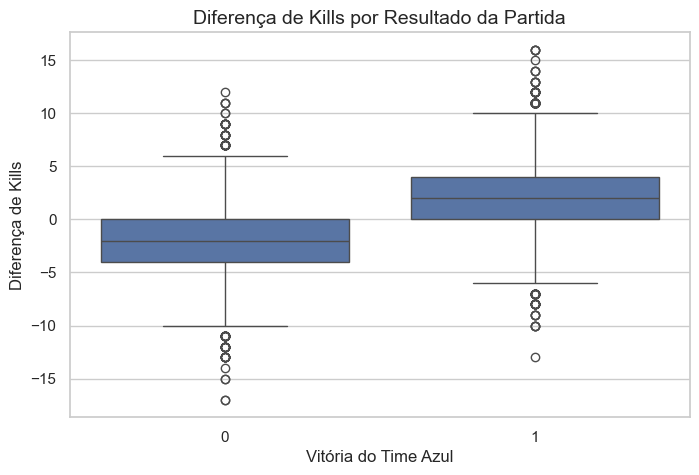

In [7]:
sns.set_theme(style="whitegrid", palette="deep")

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_dados,
    x="blueWins",
    y="blueKillsDiff",
)

plt.title("Diferença de Kills por Resultado da Partida", fontsize=14)
plt.xlabel("Vitória do Time Azul")
plt.ylabel("Diferença de Kills")

plt.show()

Tendo em vista o gráfico acima, somos capazes também de perceber uma possível correlaçao entre a diferença de ouro e a vitória do time azul. Em partidas que o time azul ganhou, os dados estão mais distribuidos na região positiva do gráfico. O oposto acontece quando o time azul perde a partida.

A diferença de Cs não desloca tanto a distribuição dos dados como quando relacionamos a diferença de abates. Isto indica que talvez o Creep Score talvez não tenha impacto de forma tão direta quanto os abtes no resultado da partida.

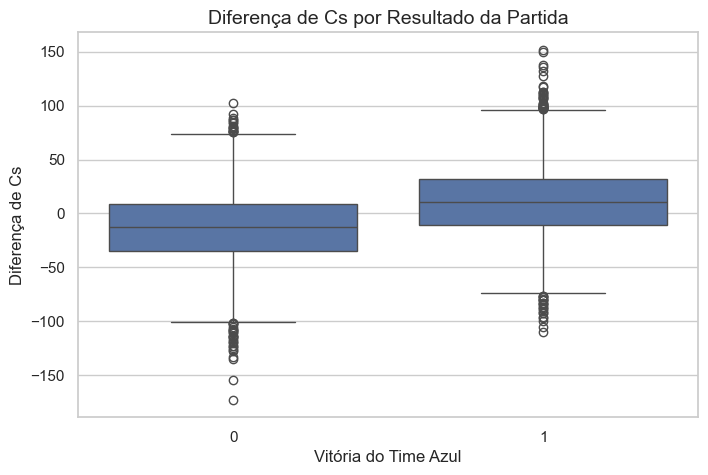

In [8]:
sns.set_theme(style="whitegrid", palette="deep")

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_dados,
    x="blueWins",
    y="blueCsDiff",
)

plt.title("Diferença de Cs por Resultado da Partida", fontsize=14)
plt.xlabel("Vitória do Time Azul")
plt.ylabel("Diferença de Cs")

plt.show()

Ao contrário dos gráficos anteriores, a diferença de sentinelas não aparenta impactar de maneira deterministica no resultado da partida. Tanto nas derrotas, quanto nas vitórias a distribuição das sentinelas não aparenta se deslocar. 

Ao mesmo tempo, o seaborn indica muitos dados que talvez sejam anomalos, o que mostra que o número de sentinelas colocadas por partidas variam bastante.

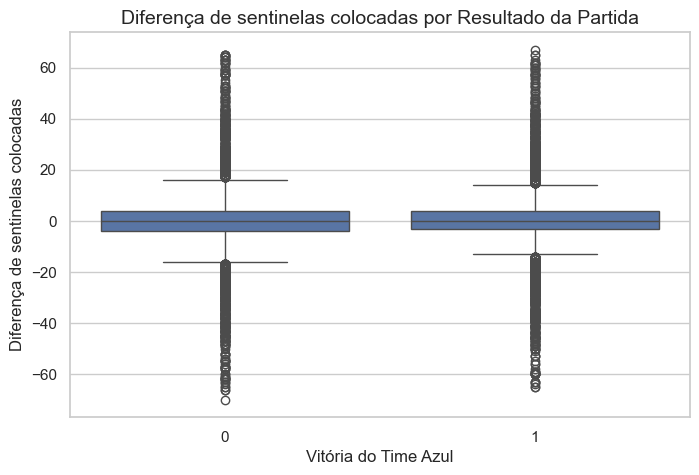

In [9]:
sns.set_theme(style="whitegrid", palette="deep")

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_dados,
    x="blueWins",
    y="blueWardsDiff",
)

plt.title("Diferença de sentinelas colocadas por Resultado da Partida", fontsize=14)
plt.xlabel("Vitória do Time Azul")
plt.ylabel("Diferença de sentinelas colocadas")

plt.show()

## Modelos

Esta seção é onde finalmente induziremos os modelos para prevermos a vitória do time azul. Após separarmos os dados de treino e teste, um modelo baseline será comparado ao modelo K-NN que obtivemos, este que será comparado com a variação dos hiperparâmetros do nosso modelo.

Primeiro veremos a métrica de desempenho que guiará a análise dos modelos posteriores.

### Porque utilizar da acurácia?

Abaixo vemos a fundação da acurácia, a matriz de confusão:
$$
\begin{array}{c|cc}
 & \text{Predito: Vitória} & \text{Predito: Derrota} \\ \hline
\text{Real: Vitória} & VP & FN \\
\text{Real: Derrota} & FP & VN
\end{array}
$$

Ela armazena os as previsões que o modelo acertou $\text{(VP, VN)}$ junto das previsões que modelo errou $\text{(FN, FP)}$. O calculo da acurácia então é realizado pelo quanto o modelo acertou por quantas previsões ele fez, logo: $$\frac{VP+VN}{VP+VN+FN+FP}$$

A acurácia portanto é util pois temos um problema de classificação. Isto permite que identifiquemos quanto o nosso modelo acerta dentre as previsões que ele faz, e ao maximizarmos a acurácia, mais eficiente se torna nosso modelo.

### Separação dos Dados de Teste e Treino

Separamos então nosso target de nossos atributos.

In [10]:
ATRIBUTOS = ["blueFirstBlood","blueDragons","blueCsDiff","blueWardsDiff","blueKillsDiff"]
TARGET = ["blueWins"]

Separamos os dados em teste e treino atráves do Scikit. Cerca de $10\%$ dos dados foram separados como dados de teste, e padronizados por uma semente aleatória com o objetivo de replicabilidade.

In [11]:
TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 61455

indices = df_dados.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

df_treino = df_dados.loc[indices_treino]
df_teste = df_dados.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

### Normalização dos dados

Os dados foram normalizados com o objetivo de melhorar a performaçe do modelo, já que anteriormente tinhamos dados binários de 0 e 1 e dados que iam até 3 algarismos, o que criaria um desequilíbrio nas previsões.

Os dados foram padronizados pela normalização padrão, centrando os dados em zero, utilizando do StandardScaler do Scikit.

In [12]:
scaler = StandardScaler()

X_treino = scaler.fit_transform(X_treino)
X_teste = scaler.transform(X_teste)

Visualize abaixo alguns dos dados normalizados

In [13]:
print(X_treino)
print("")
print(X_teste)

[[ 0.99224521  1.32419462  3.21397509  0.38527838  2.12593278]
 [-1.00781539 -0.755176   -0.33097043  0.00669085 -1.20517235]
 [-1.00781539 -0.755176    0.29797152 -1.57075719  1.17418846]
 ...
 [-1.00781539 -0.755176    0.29797152  0.00669085 -0.96723627]
 [-1.00781539 -0.755176   -0.70261795  0.57457215  0.22244414]
 [-1.00781539 -0.755176   -1.16003027  0.19598462 -1.68104451]]

[[-1.00781539 -0.755176    1.04126654  0.95315968  0.6983163 ]
 [ 0.99224521  1.32419462  0.81256038  0.4483763   1.8879967 ]
 [ 0.99224521 -0.755176   -1.01708892 -0.05640707  0.46038022]
 ...
 [-1.00781539 -0.755176   -0.73120622 -0.4349946  -0.72930019]
 [-1.00781539 -0.755176    0.32655979  1.83653058 -1.20517235]
 [-1.00781539 -0.755176    1.06985481  0.00669085 -0.72930019]]


### Modelo Baseline

Para obter uma base para futuras análises do modelo K-NN, um modelo baseline foi induzido. A acurácia, utilizando-se da matriz de confusão, foi utilizada como função de ganho para medir a eficácia do baseline.

Abaixo iremos criar a instância do modelo baseline e ajustaremos o modelo com base nos dados de treino normalizados que separamos anteriormente.

In [14]:
modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsto = modelo_baseline.predict(X_teste)

acc_base = accuracy_score(y_teste, y_previsto)
print(f"A Acurácia do modelo Baseline foi de {acc_base:.4f}")

A Acurácia do modelo Baseline foi de 0.4809


Uma matriz de confusão é um agrupamento de quais previsões foram bem sucedidas e quais não. Pelo modelo baseline de um problema de classificação ser baseado na moda dos dados, todos as previsões foram estipuladas como vitórias. O "1" na matriz representa a vitória do time azul e "0" a derrota, o eixo x representa os valores previstos e o eixo y os valores reais.

A matriz de confusão graficada abaixo torna visível o número de $0.48 = \LARGE{\frac{450}{450+490}}$ calculado pela acurácia, e mesmo que este seja um valor que signifique que o modelo erre mais que 50% das vezes, ele mostra uma linha que os proximos modelos devem superar.

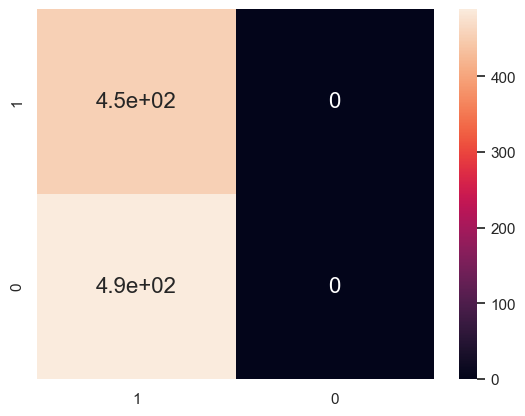

In [15]:
ordem_labels=[1,0]
matriz_conf = confusion_matrix(y_verdadeiro, y_previsto, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

### Modelo K-NN

Como forma de comparação inicial entre o modelo baseline e o modelo K-NN, inicialmente com 3 vizinhos, o modelo apresenta uma acurácia de 0.65, ou seja, acerta cerca de 65% das vezes, um bom incremento em relação ao valor obtido pelo baseline.

Abaixo iremos criar a instância do modelo K-NN e ajustaremos o modelo com base nos dados de treino normalizados que separamos anteriormente.

In [16]:
NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsto = modelo_knn.predict(X_teste)

acc_K3 = accuracy_score(y_teste, y_previsto)
print(f"A Acurácia do modelo K-NN com {NUM_VIZINHOS} vizinhos foi de {acc_K3:.4f}")

A Acurácia do modelo K-NN com 3 vizinhos foi de 0.6592


A Matriz de confusão abaixo também reflete a acurácia obtida acima de $0.65 = \LARGE{\frac{300+320}{170+150+300+320}}$. Ou seja, uma previsão inicial com 3 vizinhos já nos proporcionou um modelo com maior qualidade que o baseline.

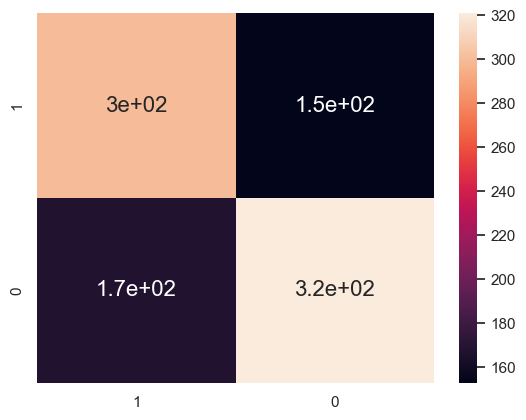

In [17]:
matriz_conf = confusion_matrix(y_verdadeiro, y_previsto, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

Podemos visualizar abaixo o aumento relativo da acurácia entre os dois modelos

In [18]:
acc_relativa1 = ((acc_K3-acc_base)*100/acc_base)

print(f"O modelo K-NN com 3 vizinhos teve um aumento relativo de {acc_relativa1:.2f}% em relaçao ao modelo baseline.")

O modelo K-NN com 3 vizinhos teve um aumento relativo de 37.09% em relaçao ao modelo baseline.


#### Variando Hiperparâmetros

Para explorarmos como o modelo se comporta com diferentes hiperparametros, veremos na célula abaixo diversas combinações destes. Os hiperparametros que estarão em foco serão o número de vizinhos, se existe algum peso entre os vizinhos com base na distância, e qual a métrica utilizda para calcular a distância.

As diversas acurácias obtidas através das combinações foram armazenadas em um dicionario e transformadas em um data frame, em ordem decrescente.

In [19]:
resultados = []

NUM_VIZINHOS = [5, 15, 30, 50, 80, 100, 200, 250]
PESOS = ["uniform", "distance"]
METRICA = ["manhattan", "minkowski"]

for n_vizinhos, metricas, peso in product(NUM_VIZINHOS, METRICA, PESOS):
    modelo_knn = KNeighborsClassifier(
        n_neighbors=n_vizinhos,
        metric=metricas,
        weights=peso
    )
    
    modelo_knn.fit(X_treino, y_treino)

    X_verdadeiro = X_teste
    y_verdadeiro = y_teste

    y_previsto = modelo_knn.predict(X_verdadeiro)

    acc = accuracy_score(y_teste, y_previsto)

    resultados.append({ "vizinhos": n_vizinhos, "métrica": metricas, "peso": peso, "acurácia": acc }) 
    
df_resultados = pd.DataFrame(resultados) 
df_resultados = df_resultados.sort_values( "acurácia", ascending=False )
df_resultados

,vizinhos,métrica,peso,acurácia
14,50,minkowski,uniform,0.739915
20,100,manhattan,uniform,0.728238
24,200,manhattan,uniform,0.725053
22,100,minkowski,uniform,0.723992
16,80,manhattan,uniform,0.722930
31,250,minkowski,distance,0.722930
26,200,minkowski,uniform,0.721868
30,250,minkowski,uniform,0.720807
18,80,minkowski,uniform,0.719745
12,50,manhattan,uniform,0.719745


In [20]:
acc_hiperparametros = df_resultados["acurácia"].iloc[0]
acc_relativa = (acc_hiperparametros - acc_base) * 100 / acc_base
acc_relativa2 = (acc_hiperparametros - acc_K3) * 100 / acc_K3


print(f"O melhor conjunto de hiperpametros teve uma acurácia relativa de {acc_relativa:.2f}% em relação ao modelo baseline e uma acurácia relativa de {acc_relativa2:.2f}% em comparação com o modelo K-NN com 3 vizinhos")

O melhor conjunto de hiperpametros teve uma acurácia relativa de 53.86% em relação ao modelo baseline e uma acurácia relativa de 12.24% em comparação com o modelo K-NN com 3 vizinhos


Por fim, é possível argumentar que devido ao volume de aproximadamente 10.000 exemplos do banco de dados, quando aumentamos o número de vizinhos de modelo, a eficiência também aumenta, contudo apenas até um valor de 50 vizinhos. A partir deste valor a qualidade do modelo atinge um plato e começa a decair. É perceptível que um baixo número de vizinhos também tem um impacto negativo na previsão do modelo, tornando o mais enviesado.

## Descrição do uso de IA neste trabalho

A inteligência artificial foi utilizada como ferramenta de apoio para revisão do código, identificação de possíveis problemas, explicação de conceitos de aprendizado de máquina e organização da estrutura do notebook. 

Ao Microssoft Copilot eu pedi ajuda em relaçao aos gráficos pertencentes a seção : Visualização Gráfica das Vitórias. 

Ao ChatGPT eu mandei meu caderno para ter um guia naquilo que eu precisava melhorar, no momento que eu pedi ajuda o caderno ainda estava inacabado então muita das coisas que me foram apontadas naturalmente seriam realizadas. Contudo, transformar os resultados dos hiperparâmetros em um dataframe e como melhorar organização do meu caderno foram os principais auxilios que a IA me trouxe.

O link para a conversa com o ChatGPT está disponível nas referências deste caderno.

## Conclusão e Aprendizados

Neste estudo foi analisado um problema de classificação utilizando dados observados aos 10 minutos de partidas de *League of Legends*. A comparação entre um baseline e diferentes configurações do K-NN permite verificar o impacto dos atributos escolhidos e dos hiperparâmetros no desempenho da classificação. Para este conjunto de dados, um modelo que abrange cerca de 50 vizinhos se mostrou mais util na previsão de futuros jogos com base nos seus 10 minutos iniciais. Contudo estas considerações estão baseadas em um unico split de dados realizados, então o melhor modelo adquirido nesta tarefa foi delineado com base apenas nestes dados e talvez apresente resultados muito particulares. Possivelmente em splits diferentes um modelo com 300, 200 ou 100 vizinhos se demonstre melhor do que o que obtivemos neste caderno, ou talvez demonstre que este caderno possui uma acurácia superestimada.

Este caderno permitiu visualizar através de gráficos como a distribuição de certos atributos se relaciona com as vitórias do time azul, e através normalização dos dados obtivemos um modelo que detem um melhor desempenho.

Foi possível aprender como realizar a indução de modelos K-NN e torna-los mais confiáveis, como utilizar de métricas de desempenho para descreve-los e utiliza-las para comparar dois modelos diferentes.

## Referências


1. DataSet [https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/data?select=high_diamond_ranked_10min.csv](https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/data?select=high_diamond_ranked_10min.csv)

2. Inspiração para o uso do DataSet [https://mneskovic.github.io/](https://mneskovic.github.io/)

3. Link para conversa com ChatGPT [https://chatgpt.com/share/6aa5e3c9-c354-83e9-9ef2-b733c57db7d7](https://chatgpt.com/share/6aa5e3c9-c354-83e9-9ef2-b733c57db7d7)

4. Cadernos Jupyter utilizados na aula de aprendizado de maquina

   * 1.1 - Tratamento de dados com pandas
   * 2.1 - Aprendizado de máquina, k-NN e métricas
   * 2.2 - Divisão de dados em treino e teste
   * 3.0 - Modelo linear e baseline
   * 4.0 - Árvore de decisão e floresta aleatória
   * 5.0 - Classificação binária